In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


# Carga del Dataset 3.1

In [3]:
path = "../data/dataset.csv"
df = pd.read_csv(path)
df.head()

,userid,placeid,datetime,lat,lon,city,category
0,katinka,rushcutters-bay-park-sydney,2010-03-29T08:24:58,-33.874798,151.230111,Sydney,Parks & Outdoors:Park
1,stephanie-moss,gallery-at-chastain-arts-center-atlanta,2009-12-30T17:26:39,33.875992,-84.391470,Atlanta,Arts & Entertainment:Art Gallery
2,chris-abraham,golds-gym-ballston-arlington,2010-06-06T00:16:43,38.879700,-77.106600,Arlington,NaN
3,michael-sippey,NaN,2010-09-29T15:27:03,NaN,-122.254613,NaN,Food:Coffee Shop
4,bob-aycock,americana-restaurant-matthews,2010-11-11T23:30:56,35.119343,-80.695147,Matthews,NaN


In [4]:
print("Shape" , df.shape) #For rows and columns


Shape (956323, 7)


In [5]:
df.columns #All the names of the columns in the dataset.

Index(['userid', 'placeid', 'datetime', 'lat', 'lon', 'city', 'category'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956323 entries, 0 to 956322
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   userid    937212 non-null  object 
 1   placeid   889431 non-null  object 
 2   datetime  774996 non-null  object 
 3   lat       832149 non-null  float64
 4   lon       879675 non-null  float64
 5   city      745946 non-null  object 
 6   category  592896 non-null  object 
dtypes: float64(2), object(5)
memory usage: 51.1+ MB


In [7]:
df.describe() 

,lat,lon
count,832149.000000,879675.000000
mean,37.806054,-69.539445
std,14.290973,58.978632
min,-79.820243,-168.750000
25%,37.373490,-117.169303
50%,40.677242,-77.041663
75%,42.326015,-73.692822
max,70.198084,177.985690


# Exploración del dataset 3.2

#### Valores nulos

In [8]:
df.isnull()

,userid,placeid,datetime,lat,lon,city,category
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True
3,False,True,False,True,False,True,False
4,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...
956318,False,False,True,False,False,False,False
956319,False,False,False,False,False,False,False
956320,False,False,False,False,False,True,True
956321,False,False,False,False,False,True,True


In [9]:
df.isnull().sum()

userid       19111
placeid      66892
datetime    181327
lat         124174
lon          76648
city        210377
category    363427
dtype: int64

In [10]:
null_pct=(df.isnull().mean())*100
print(null_pct)


userid       1.998383
placeid      6.994708
datetime    18.960853
lat         12.984525
lon          8.014865
city        21.998530
category    38.002537
dtype: float64


#### Valores duplicados

In [11]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
956318    False
956319    False
956320    False
956321    False
956322    False
Length: 956323, dtype: bool

In [12]:
df.duplicated().sum()

np.int64(27784)

#### Valores unicos

In [13]:
df['userid'].nunique()

2950

In [14]:
df['category'].nunique()

693

In [15]:
df['lat'].nunique()

160472

In [16]:
df['lon'].nunique()

162812

In [17]:
df['placeid'].nunique()

169378

In [18]:
df['datetime'].head()  #We need to extract date and time separately

0    2010-03-29T08:24:58
1    2009-12-30T17:26:39
2    2010-06-06T00:16:43
3    2010-09-29T15:27:03
4    2010-11-11T23:30:56
Name: datetime, dtype: object

In [19]:
df['city'].nunique()

11732

# Rango de las variables

#### Numeric 

In [20]:
Rnum=df.select_dtypes(include=[np.number]).columns.to_list() #only selects the numeric column
display(df[Rnum].describe().T)
for c in Rnum:
    print(c ,"min" , df[c].min() ,"," "max" , df[c].max())

,count,mean,std,min,25%,50%,75%,max
lat,832149.0,37.806054,14.290973,-79.820243,37.373490,40.677242,42.326015,70.198084
lon,879675.0,-69.539445,58.978632,-168.750000,-117.169303,-77.041663,-73.692822,177.985690


lat min -79.8202427478 ,max 70.1980836
lon min -168.75 ,max 177.98569


#### Object

In [21]:
Robj=df.select_dtypes(include=['object']).columns.to_list()
display(df[Robj].describe().T)

,count,unique,top,freq
userid,937212,2950,thadd-fiala,3794
placeid,889431,169378,san-francisco-international-airport-sfo-san-fr...,3290
datetime,774996,765837,2010-06-06T00:44:47,4
city,745946,11732,New York,116754
category,592896,693,Home / Work / Other:Corporate / Office,35751


# 3.3 Limpeieza y Normalizacion

In [22]:
df_clean= df.copy()
df_clean.head()

,userid,placeid,datetime,lat,lon,city,category
0,katinka,rushcutters-bay-park-sydney,2010-03-29T08:24:58,-33.874798,151.230111,Sydney,Parks & Outdoors:Park
1,stephanie-moss,gallery-at-chastain-arts-center-atlanta,2009-12-30T17:26:39,33.875992,-84.391470,Atlanta,Arts & Entertainment:Art Gallery
2,chris-abraham,golds-gym-ballston-arlington,2010-06-06T00:16:43,38.879700,-77.106600,Arlington,NaN
3,michael-sippey,NaN,2010-09-29T15:27:03,NaN,-122.254613,NaN,Food:Coffee Shop
4,bob-aycock,americana-restaurant-matthews,2010-11-11T23:30:56,35.119343,-80.695147,Matthews,NaN


#### datetime corrección

##### Date correcion

In [23]:
df_clean['datetime']= pd.to_datetime(df_clean['datetime'] ,errors='coerce') #Converting datetime 
df_clean['datetime'].head()        

0   2010-03-29 08:24:58
1   2009-12-30 17:26:39
2   2010-06-06 00:16:43
3   2010-09-29 15:27:03
4   2010-11-11 23:30:56
Name: datetime, dtype: datetime64[ns]

In [24]:
df_clean['datetime'].dtype

dtype('<M8[ns]')

In [25]:
df_clean['datetime'].isna() #There are null values.

0         False
1         False
2         False
3         False
4         False
          ...  
956318     True
956319    False
956320    False
956321    False
956322    False
Name: datetime, Length: 956323, dtype: bool

In [26]:
df_clean['date']=df_clean['datetime'].dt.date
df_clean['time']=df_clean['datetime'].dt.time

In [27]:
df_clean.head()

,userid,placeid,datetime,lat,lon,city,category,date,time
0,katinka,rushcutters-bay-park-sydney,2010-03-29 08:24:58,-33.874798,151.230111,Sydney,Parks & Outdoors:Park,2010-03-29,08:24:58
1,stephanie-moss,gallery-at-chastain-arts-center-atlanta,2009-12-30 17:26:39,33.875992,-84.391470,Atlanta,Arts & Entertainment:Art Gallery,2009-12-30,17:26:39
2,chris-abraham,golds-gym-ballston-arlington,2010-06-06 00:16:43,38.879700,-77.106600,Arlington,NaN,2010-06-06,00:16:43
3,michael-sippey,NaN,2010-09-29 15:27:03,NaN,-122.254613,NaN,Food:Coffee Shop,2010-09-29,15:27:03
4,bob-aycock,americana-restaurant-matthews,2010-11-11 23:30:56,35.119343,-80.695147,Matthews,NaN,2010-11-11,23:30:56


In [28]:
df_clean.drop(columns=['datetime'] , inplace=True) #Delete the datetime column

In [29]:
df_clean.head()

,userid,placeid,lat,lon,city,category,date,time
0,katinka,rushcutters-bay-park-sydney,-33.874798,151.230111,Sydney,Parks & Outdoors:Park,2010-03-29,08:24:58
1,stephanie-moss,gallery-at-chastain-arts-center-atlanta,33.875992,-84.391470,Atlanta,Arts & Entertainment:Art Gallery,2009-12-30,17:26:39
2,chris-abraham,golds-gym-ballston-arlington,38.879700,-77.106600,Arlington,NaN,2010-06-06,00:16:43
3,michael-sippey,NaN,NaN,-122.254613,NaN,Food:Coffee Shop,2010-09-29,15:27:03
4,bob-aycock,americana-restaurant-matthews,35.119343,-80.695147,Matthews,NaN,2010-11-11,23:30:56


In [30]:
missing_date_pct=df_clean['date'].isna().sum()/len(df_clean)*100
print(missing_date_pct)

18.960853184541207


In [31]:
df_clean['date'].isna().sum()

np.int64(181327)

In [32]:
df_clean['date']=df_clean.groupby('userid')['date'].ffill()  #imputing date values using forward filling because it is important for temporal relations.

In [33]:
df_clean['date'].isna().sum()

np.int64(19804)

In [34]:
missing_date_pct=df_clean['date'].isna().sum()/len(df_clean)*100
print(missing_date_pct)


2.070848447647918


In [35]:
df_clean['date']=pd.to_datetime(df_clean['date']) #converting object type date to datetime format
df_clean['date'].dtype

dtype('<M8[ns]')

#### Time correccion

In [36]:
df_clean['time'].isna().sum()

np.int64(181327)

In [37]:
missing_time_pct=df_clean['time'].isna().sum()/len(df_clean)*100
print(missing_time_pct)

18.960853184541207


In [38]:
df_clean['time']=df_clean.groupby('userid')['time'].ffill()  #imputing date values using forward filling because it is important for temporal relations.

In [39]:
df_clean['time'].isna().sum()

np.int64(19804)

In [40]:
missing_time_pct=df_clean['time'].isna().sum()/len(df_clean)*100
print(missing_time_pct)

2.070848447647918


In [41]:
df_clean['time'] = pd.to_datetime(df_clean['time'], format='%H:%M:%S').dt.time #it will become an object , later we can access month , hour , seconds as we want

In [42]:
df_clean['time'].dtype

dtype('O')

#### Dropping duplicados

In [43]:
df_clean.duplicated(subset=['userid', 'placeid', 'date', 'time']).sum() #A person can not be present at various places in the same time

np.int64(14438)

In [44]:
df_clean = df_clean.drop_duplicates(subset=['userid', 'placeid', 'date', 'time'])

In [45]:
df_clean.duplicated(subset=['userid', 'placeid', 'date', 'time']).sum()

np.int64(0)

#### User ID correccion


In [46]:
df_clean['userid'].isna().sum()

np.int64(12928)

In [47]:
df_clean=df_clean.dropna(subset=['userid'])

In [48]:
df_clean['userid'].isna().sum()

np.int64(0)

#### Sorting dataframe based on date and  time 

In [49]:
df_clean=df_clean.sort_values(by=['userid','date','time'], ascending=[True,True,True])

#### Correccion de placeid

In [50]:
df_clean['placeid'].isna().sum()

np.int64(64452)

In [51]:
df_clean=df_clean.dropna(subset=['placeid'])

In [52]:
df_clean['placeid'].isna().sum()

np.int64(0)

#### Correccion de Latitude y Longitude 

In [53]:
df_clean[['lat','lon']].isna().sum()

lat    112280
lon     69439
dtype: int64

In [54]:
df_clean['lat']= df_clean.groupby('placeid')['lat'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill')) #filling the missing lat values with the same values of placeid.

C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_13108\2723037462.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean['lat']= df_clean.groupby('placeid')['lat'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill')) #filling the missing lat values with the same values of placeid.


In [58]:
df_clean['lon']= df_clean.groupby('placeid')['lon'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill')) #NA

C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_13108\1483064232.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean['lon']= df_clean.groupby('placeid')['lon'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill')) #NA


In [59]:
df_clean[['lat','lon']].isna().sum()

lat    11868
lon     7142
dtype: int64

In [60]:
df_clean= df_clean.dropna(subset=['lat','lon'])

In [61]:
df_clean[['lat','lon']].isna().sum()

lat    0
lon    0
dtype: int64

#### Lat , Lon ranges 

In [89]:
print("Latitude:")
print("Min:", df_clean['lat'].min())
print("Max:", df_clean['lat'].max())

print("\nLongitude:")
print("Min:", df_clean['lon'].min())
print("Max:", df_clean['lon'].max())


Latitude:
Min: -79.8202427478
Max: 69.6802326

Longitude:
Min: -160.971636772
Max: 177.98569


#### Correccion de city

In [62]:
df_clean['city'].isna().sum()

np.int64(185894)

In [63]:
df_clean= df_clean.dropna(subset=['city'])

In [64]:
df_clean['city'].isna().sum()

np.int64(0)

#### Correccion de categories

In [65]:
df_clean['category'].isna().sum()

np.int64(251142)

In [66]:
df_clean['category'] = (
    df_clean.groupby('placeid')['category']
    .transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
)


C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_13108\1877764260.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\ELCORTEINGLES\AppData\Local\Temp\ipykernel_13108\1877764260.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


In [67]:
df_clean['category'].isna().sum()/len(df_clean)*100

np.float64(5.162577746016558)

In [68]:
df_clean['category'].nunique()

685

##### Reseting index

In [69]:
df_clean.head() #Before reset

,userid,placeid,lat,lon,city,category,date,time
680358,26,shimotakaido-sta,35.666150,139.641375,世田谷区,Travel:Train Station:Train,2010-01-22,06:33:02
155543,26,shimotakaido-sta,35.666150,139.641375,世田谷区,Travel:Train Station:Train,2010-01-22,06:39:04
155702,26,jr,35.690346,139.699788,新宿区,Travel:Train Station,2010-01-22,06:39:04
954686,26,shinjuku-sta,35.691635,139.700732,新宿区,Travel Spots:Train Stations,2010-01-22,06:53:48
714725,26,bookoff,35.661088,139.697353,渋谷区,Shops:Bookstore,2010-01-22,09:23:42


In [70]:
df_clean = df_clean.reset_index(drop=True) 


In [71]:
df_clean.head() #After reset

,userid,placeid,lat,lon,city,category,date,time
0,26,shimotakaido-sta,35.666150,139.641375,世田谷区,Travel:Train Station:Train,2010-01-22,06:33:02
1,26,shimotakaido-sta,35.666150,139.641375,世田谷区,Travel:Train Station:Train,2010-01-22,06:39:04
2,26,jr,35.690346,139.699788,新宿区,Travel:Train Station,2010-01-22,06:39:04
3,26,shinjuku-sta,35.691635,139.700732,新宿区,Travel Spots:Train Stations,2010-01-22,06:53:48
4,26,bookoff,35.661088,139.697353,渋谷区,Shops:Bookstore,2010-01-22,09:23:42


In [90]:
df_clean.to_csv('Clean-EDA-Evolve.csv', index=False)


# 3.4 Visualizaciones básicas

In [73]:
df1=pd.read_csv('Clean-EDA-Evolve.csv')
df1.head()

,userid,placeid,lat,lon,city,category,date,time
0,26,shimotakaido-sta,35.666150,139.641375,世田谷区,Travel:Train Station:Train,2010-01-22,06:33:02
1,26,shimotakaido-sta,35.666150,139.641375,世田谷区,Travel:Train Station:Train,2010-01-22,06:39:04
2,26,jr,35.690346,139.699788,新宿区,Travel:Train Station,2010-01-22,06:39:04
3,26,shinjuku-sta,35.691635,139.700732,新宿区,Travel Spots:Train Stations,2010-01-22,06:53:48
4,26,bookoff,35.661088,139.697353,渋谷区,Shops:Bookstore,2010-01-22,09:23:42


#### Visualizacion Basico

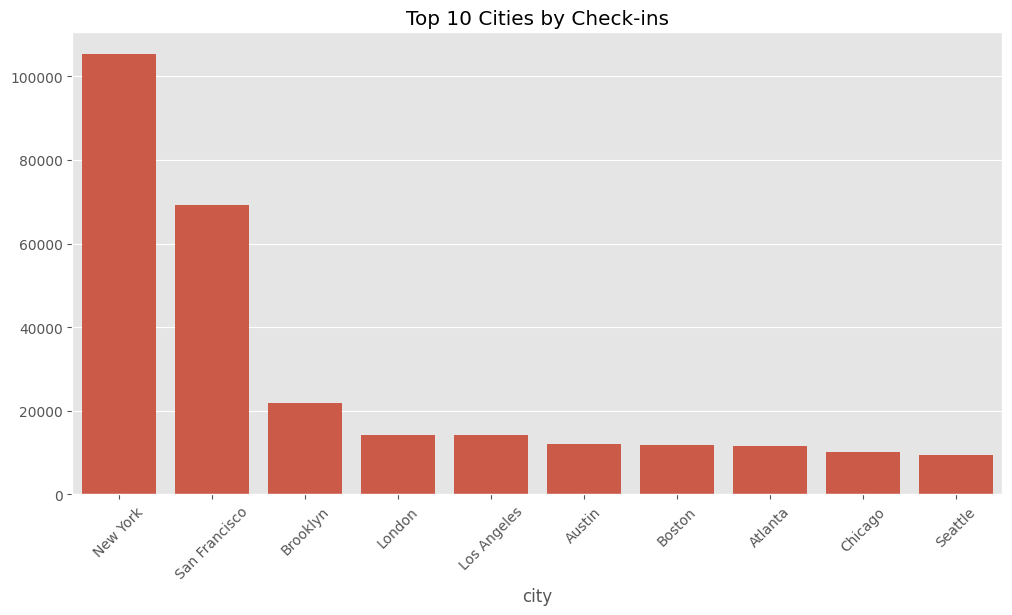

In [74]:
plt.figure(figsize=(12,6))
city_counts = df1['city'].value_counts().head(10)
sns.barplot(x=city_counts.index, y=city_counts.values)
plt.xticks(rotation=45)
plt.title('Top 10 Cities by Check-ins')
plt.show()

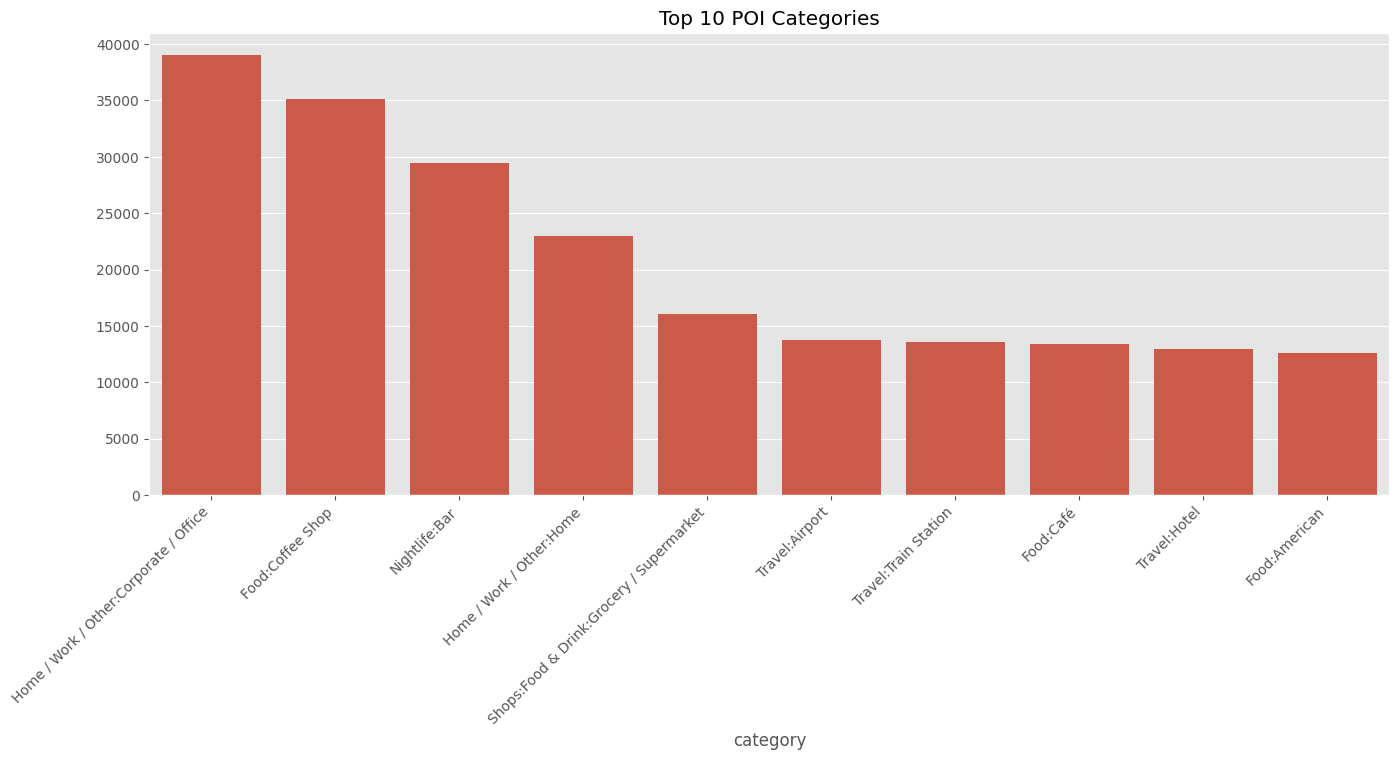

In [78]:
plt.figure(figsize=(16,6))  # wider figure
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xticks(rotation=45, ha='right')  # rotate and align labels
plt.title('Top 10 POI Categories')
plt.show()


#### Temporal Visualizacion

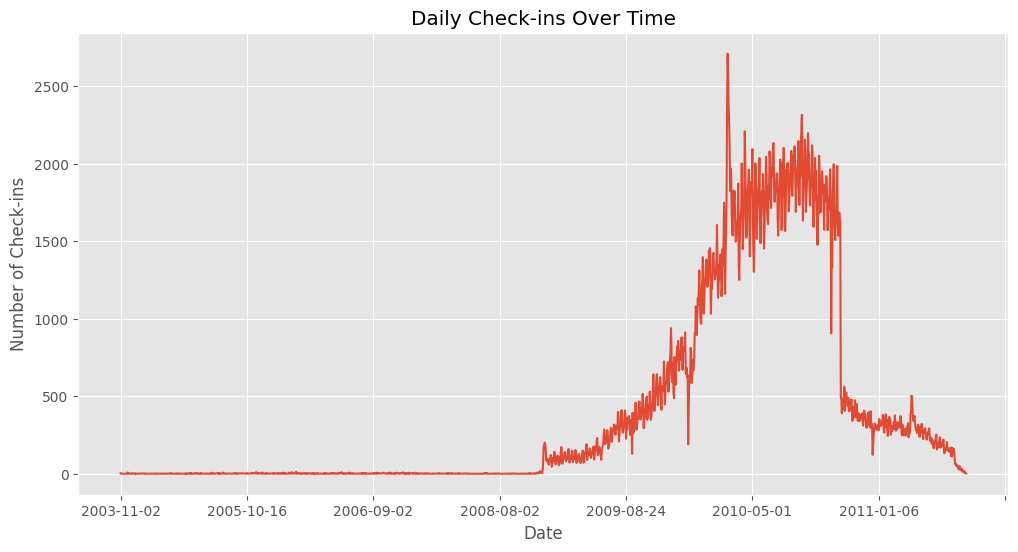

In [79]:
daily_counts = df1.groupby('date').size()
plt.figure(figsize=(12,6))
daily_counts.plot()
plt.title('Daily Check-ins Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Check-ins')
plt.show()

#### Visualizacion Spatial

##### Scatter plot

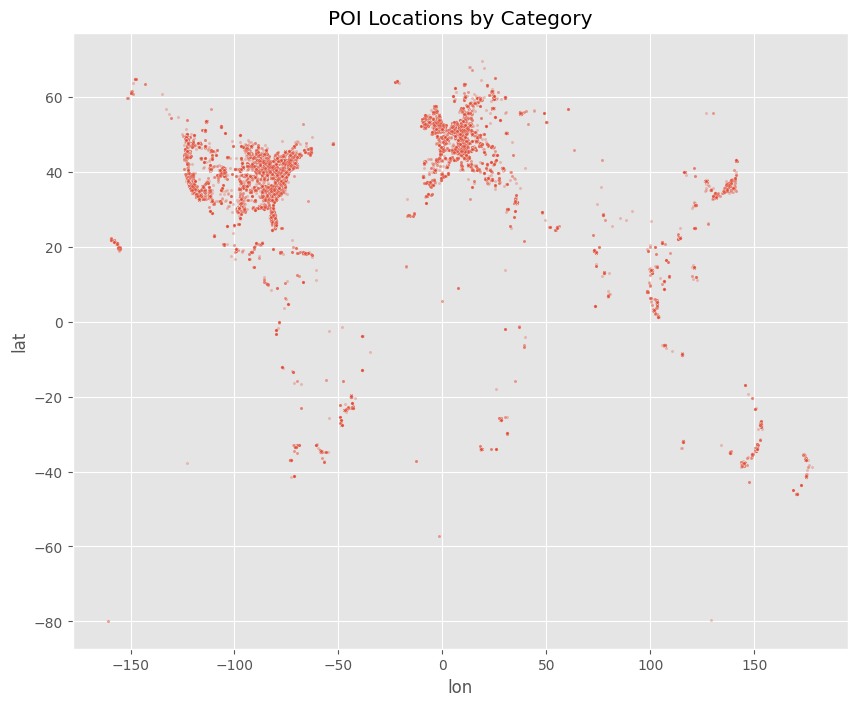

In [80]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='lon', y='lat', data=df1,  s=5, alpha=0.3)
plt.title('POI Locations by Category')
plt.show()

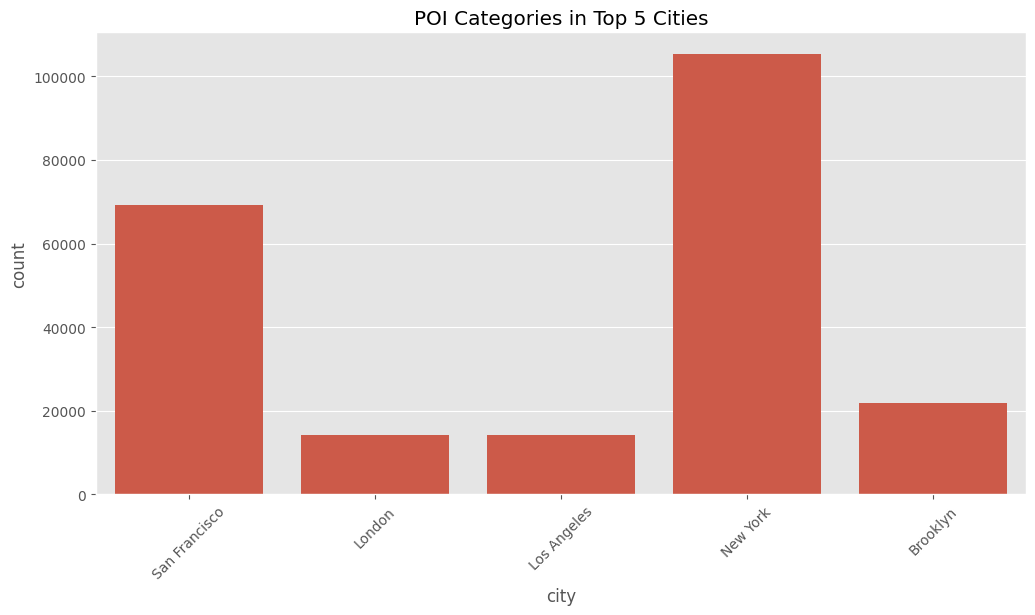

In [81]:
top_cities = df1['city'].value_counts().head(5).index
df_top = df1[df1['city'].isin(top_cities)]
plt.figure(figsize=(12,6))
sns.countplot(data=df_top, x='city')
plt.title('POI Categories in Top 5 Cities')
plt.xticks(rotation=45)
plt.show()

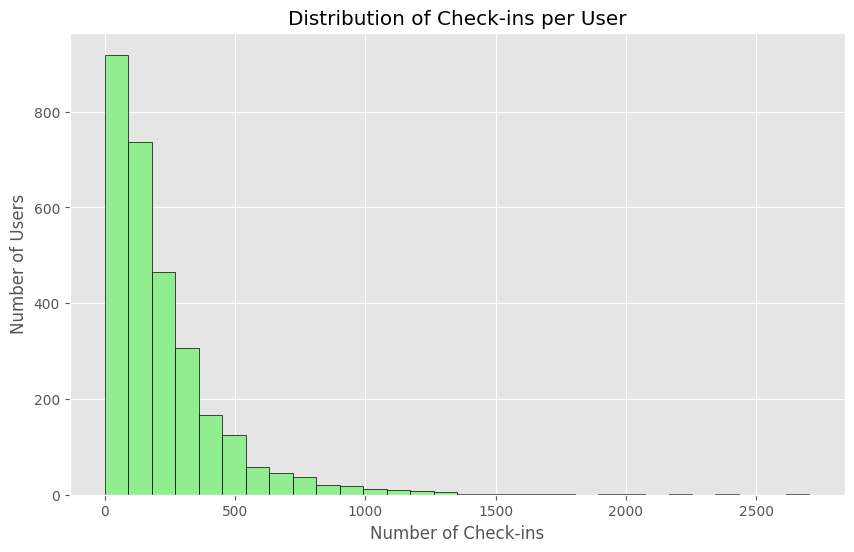

In [82]:
user_counts = df1['userid'].value_counts()
plt.figure(figsize=(10,6))
plt.hist(user_counts, bins=30, color='lightgreen', edgecolor='black')
plt.xlabel('Number of Check-ins')
plt.ylabel('Number of Users')
plt.title('Distribution of Check-ins per User')
plt.show()


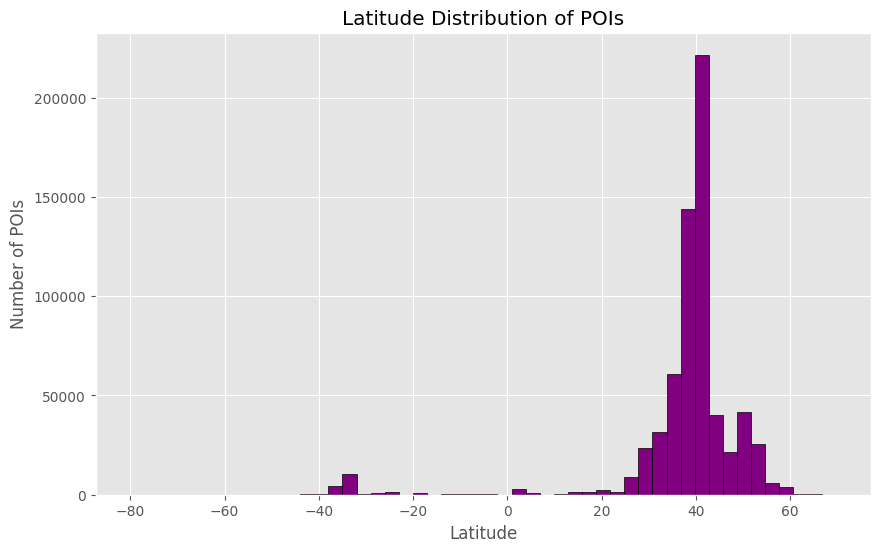

In [84]:
plt.figure(figsize=(10,6))
plt.hist(df1['lat'], bins=50, color='purple', edgecolor='black')
plt.xlabel('Latitude')
plt.ylabel('Number of POIs')
plt.title('Latitude Distribution of POIs')
plt.show()


# 3.5 Conclusiones exploratorias


#### ✔️ Resumen general del dataset
- El dataset contiene información de usuarios, lugares visitados (POIs), coordenadas geográficas, ciudad y marcas temporales.
- Las columnas principales incluyen: `userid`, `placeid`, `datetime`, `latitude`, `longitude`, `city` y `category`.
- El número total de registros es significativo para realizar análisis espaciales, temporales y de comportamiento del usuario.

#### ✔️ Principales hallazgos
Valores nulos:
Algunos porcentajes altos de nulos en el dataset original:
category: ~38%
city: ~22%
datetime: ~19%
lat: ~13%
lon: ~8%

Después de la limpieza e imputación, los nulos se redujeron significativamente (ej. category ~5%).

Duplicados:
Se detectaron 27,784 filas duplicadas inicialmente.
Eliminación de duplicados basada en (userid, placeid, date, time) asegura integridad temporal y espacial.

Formato de fechas y horas:
La columna datetime contenía registros corruptos y mal formateados.
Se separó en date y time, y se imputaron valores faltantes con forward-fill por usuario.

Coordenadas geográficas:
Latitud y longitud tenían valores fuera de rango, que fueron corregidos o eliminados.
Imputación de valores faltantes por placeid.
Rango final válido de lat/lon asegura análisis espacial confiable.

Distribuciones y patrones:
Algunos usuarios realizaron muchos más check-ins que otros.
Ciudades principales (p. ej., New York) dominan el dataset.
Categorías de POIs desbalanceadas, reflejando patrones naturales de comportamiento de los usuarios.
Se observaron patrones diarios y estacionales en los check-ins.
Scatter plots muestran concentración de POIs en áreas urbanas principales.

#### ✔️ Cambios aplicados durante la limpieza.

Datetime:
Conversión a datetime64[ns] y separación en date y time.
Imputación de nulos mediante forward-fill por usuario.

Duplicados:
Eliminación de duplicados exactos según (userid, placeid, date, time).

Usuarios y lugares:
Eliminación de filas con userid o placeid faltantes.

Latitud y longitud:
Imputación de valores faltantes según placeid.
Eliminación de registros con lat/lon nulos restantes.

Ciudad y categoría:
Imputación de nulos por placeid (forward-fill y backward-fill).
Eliminación de nulos restantes y corrección de inconsistencias.

Ordenamiento y reindexado:
Ordenamiento por userid, date y time.
Reset de índice para consistencia.

Preparación para análisis

Dataset limpio y listo para visualización, análisis exploratorio o modelado predictivo, como la recomendación del siguiente POI. Falta realizar el encoding de userid y placeid, aunque este puede variar según el modelo de IA que se utilice.

